In [26]:
import numpy as np
import RandomTilings as RT
import matplotlib.pyplot as plt
from numba import njit

# Aztec Diamond
## Copy for work

In [106]:
from numpy import zeros,array,int8,float64,ndarray,arange
from matplotlib.collections import LineCollection,PolyCollection
from matplotlib.pyplot import subplots
from numba import njit
from RandomTilings._draw_aux import _set_color

@njit("(Array(int8, 2, 'C', False, aligned=True),bool,bool,bool)",cache=True)
def compute_domino_data(M,diamond,aztec_gray,paths):
    N = M.shape[0]
    n = N//2
    if paths:
        P = zeros((n*(n+1),2,2))
    else:
        P = zeros((n*(n+1),4,2))
    C = zeros(n*(n+1),dtype=int8)
    k = 0

    if diamond:
        if paths: 
            A0 = array([[ 0. , 0. ],
                        [ 0. , 0. ]]) # nothing
            A1 = array([[-0.5, 0.5],
                        [ 0.5,-0.5]]) # diagonal down
            A2 = array([[-1. , 0. ],
                        [ 1. ,-0. ]]) # horizontal
            A3 = array([[-0.5,-0.5],
                        [ 0.5, 0.5]]) # diagonal up
        else:
            A0 = array([[ 1., 0.5],
                        [ 1.,-0.5],
                        [-1.,-0.5],
                        [-1., 0.5]])
            A1 = array([[ 0.5, 1.],
                        [-0.5, 1.],
                        [-0.5,-1.],
                        [ 0.5,-1.]])
            A2 = array([[-1.,-0.5],
                        [-1., 0.5],
                        [ 1., 0.5],
                        [ 1.,-0.5]])
            A3 = array([[-0.5,-1.],
                        [ 0.5,-1.],
                        [ 0.5, 1.],
                        [-0.5, 1.]])
    else:
        if paths:
            A0 = array([[ 0., 0.],
                        [ 0., 0.]]) # nothing
            A1 = array([[ 0., 1.],
                        [ 0.,-1.]]) # vertical
            A2 = array([[-1., 1.],
                        [ 1.,-1.]]) # diagonal
            A3 = array([[-1., 0.],
                        [ 1., 0.]]) # horizontal
        else:
            A0 = array([[ 1.5,-0.5],
                        [ 0.5,-1.5],
                        [-1.5, 0.5],
                        [-0.5, 1.5]])
            A1 = array([[ 0.5, 1.5],
                        [ 1.5, 0.5],
                        [-0.5,-1.5],
                        [-1.5,-0.5]])
            A2 = array([[-1.5, 0.5],
                        [-0.5, 1.5],
                        [ 1.5,-0.5],
                        [ 0.5,-1.5]])
            A3 = array([[-0.5,-1.5],
                        [-1.5,-0.5],
                        [ 0.5, 1.5],
                        [ 1.5, 0.5],])

    if aztec_gray:
        for x in range(N):
            for y in range(N):
                if diamond:
                    c = array([(x+y)/2,(x-y)/2],dtype=float64)
                else:
                    c = array([x+1,N-y],dtype=float64)
                if M[y,x] == 1:
                    # north
                    if x%2 == 1 and y%2 == 0:
                        P[k] = A0 + c
                        C[k] = int((x+N-y)%4 == 3)
                    # east
                    elif x%2 == 1 and y%2 == 1:
                        P[k] = A1 + c
                        C[k] = 2 + int((x-N+y)%4 == 0)
                    # south
                    elif x%2 == 0 and y%2 == 1:
                        P[k] = A2 + c
                        C[k] = 4 + int((x+N-y)%4 == 3)
                    # west
                    else:
                        P[k] = A3 + c
                        C[k] = 6 + int((x-N+y)%4 == 0)
                    k+= 1
    else:
        for x in range(N):
            for y in range(N):
                if diamond:
                    c = array([(x+y)/2,(x-y)/2],dtype=float64)
                else:
                    c = array([x+1,N-y],dtype=float64)

                if M[y,x] == 1:
                    # north
                    if x%2 == 1 and y%2 == 0:
                        P[k] = A0 + c
                        C[k] = 0
                    # east
                    elif x%2 == 1 and y%2 == 1:
                        P[k] = A1 + c
                        C[k] = 1
                    # south
                    elif x%2 == 0 and y%2 == 1:
                        P[k] = A2 + c
                        C[k] = 2
                    # west
                    else:
                        P[k] = A3 + c
                        C[k] = 3
                    k+= 1

    if paths:
        C -= 1
        I  = C>=0
        P  = P[I]
        C  = C[I]
    return P,C

def draw_dominos_dimer(M,edge_width=0,
                 orientation='diamond',color_scheme='standard',dpi=100):
    N = M.shape[0]
    n = N//2

    # Set matplotlib figure layout
    fig,ax = subplots(dpi=dpi)
    if orientation == 'diamond':
        ax.set_xlim(-1,len(M))
        ax.set_ylim(-len(M)//2-.5,len(M)//2+.5)
    elif orientation == 'square':
        ax.set_xlim(-1.5,len(M)+2.5)
        ax.set_ylim(-1.5,len(M)+2.5)
    else:
        print('Orientation not recognized.')
        raise
    ax.set_aspect('equal')
    ax.axis('off')

    # Set color scheme
    color = _set_color(color_scheme,'aztec',False)

    
    # Computing data
    P,C = compute_domino_data(M,orientation=='diamond',color_scheme=='aztec gray',False)
    ax.add_collection(PolyCollection(P,facecolor=color[C],edgecolor='k',linewidth=edge_width))


    dimer_line_size = 30/(M.shape[0]+2*M.shape[0]**0.5)
    P0 = (3/4*(P[:,0]+P[:,1]) + 1/4*(P[:,2]+P[:,3]))/2
    P1 = (1/4*(P[:,0]+P[:,1]) + 3/4*(P[:,2]+P[:,3]))/2
    Q  = np.stack([P0,P1],axis=1)
    ax.add_collection(LineCollection(Q,color = 'k',linewidth = dimer_line_size))

    dimer_dot_size = 100/(M.shape[0])
    dot_border = 10/M.shape[0]
    plt.scatter(*P0.T,color = 'k',s=dimer_dot_size,facecolor='white',zorder = 2,linewidth = dot_border)
    plt.scatter(*P1.T,color = 'k',s=dimer_dot_size,zorder = 2,linewidth = dot_border)
    return fig

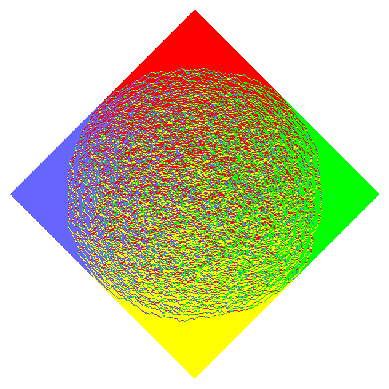

In [162]:
n = 300
A = RT.Aztec(n)
A.shuffle()
A.plot(edge_width=0)

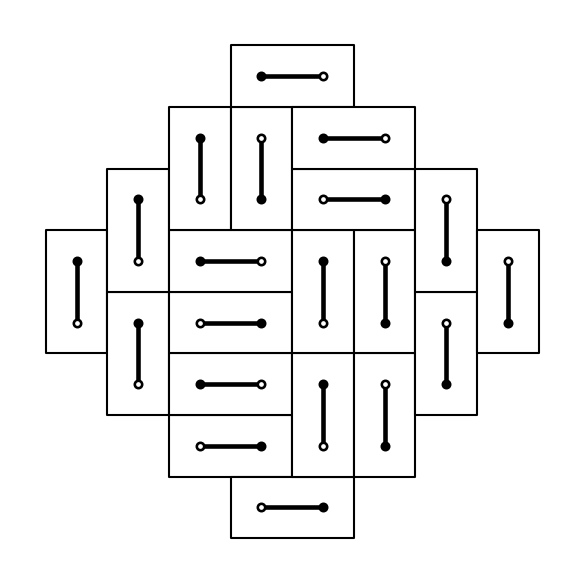

In [167]:
n = 4
A = RT.Aztec(n)
A.shuffle()
M = A.get_edge_matrix()
color = 4*[[1.,1.,1.]]
#color = 'standard'
_=draw_dominos_dimer(M,edge_width=1,orientation='diamond',dpi=150,color_scheme=color)

# Hexagon

## Copy for work

In [2]:
from matplotlib.collections import LineCollection,PolyCollection
from numba import njit
from RandomTilings._draw_aux import _set_color
@njit("(int64, int64, int64, int64, int64)",cache=True,inline="always")
def in_hexagon(x,y,A,B,C):
    if x <= 2*min(B,C):
        return y >= 1 and y <= 2*A+x-1
    elif x >= 2*C+1 and x <= 2*B:
        return y >= 1 and y <= 2*(A+C)-1
    elif x >= 2*B+1 and x <= 2*C:
        return y >= x-2*B+1 and y <= 2*A+x-1
    elif x >= 2*max(B,C)+1 and x <= 2*(B+C)-1:
        return y >= x-2*B+1 and y <= 2*(A+C)-1
    else:
        return False

@njit("(int64, int64)",cache=True,inline="always")
def type_of_lozenge(x,y):
    # path up
    if x%2 == 1 and y%2 == 0:
        return 0
    # path down
    elif x%2 == 1 and y%2 == 1:
        return 1
    # free of path
    else:
        return 2

@njit("(int64, int64, bool)",cache=True,inline="always")
def points_lozenge(x,y,regular):
    type_loz = type_of_lozenge(x,y)
    if type_loz == 0:
        if regular:
            A = np.array([[x-1,y-(x-1)//2-2],
                       [x-1,y-(x-1)//2  ],
                       [x+1,y-(x+1)//2+2],
                       [x+1,y-(x+1)//2  ]])
        else:
            A = np.array([[x-1,y-2],
                       [x-1,y  ],
                       [x+1,y+2],
                       [x+1,y  ]])
    elif type_loz == 1:
        if regular:
            A = np.array([[x-1,y-(x-1)//2-1],
                       [x-1,y-(x-1)//2+1],
                       [x+1,y-(x+1)//2+1],
                       [x+1,y-(x+1)//2-1]])
        else:
            A = np.array([[x-1,y-1],
                       [x-1,y+1],
                       [x+1,y+1],
                       [x+1,y-1]])
    else:
        if regular:
            A = np.array([[x-2,y-x//2  ],
                       [x  ,y-x//2+1],
                       [x+2,y-x//2  ],
                       [x  ,y-x//2-1]])
        else:
            A = np.array([[x-2,y-1],
                       [x  ,y+1],
                       [x+2,y+1],
                       [x  ,y-1]])
    return A,type_loz

@njit("(int64, int64, bool)",cache=True,inline="always")
def points_path(x,y,regular):
    type_loz = type_of_lozenge(x,y)
    if type_loz == 0:
        if regular:
            A = np.array([[x-1,y-1-(x-1)//2],[x+1,y+1-(x+1)//2]])
        else:
            A = np.array([[x-1,y-1],[x+1,y+1]])
    elif type_loz == 1:
        if regular:
            A = np.array([[x-1,y-(x-1)//2],[x+1,y-(x+1)//2]])
        else:
            A = np.array([[x-1,y],[x+1,y]])
    else:
        A = np.array([[0,0],[0,0]])
    return A,type_loz

@njit("(Array(int8, 2, 'C', False, aligned=True), int64, int64, int64, bool, bool)",cache=True)
def compute_hexagon_data(M,A,B,C,regular,paths):
    N = M.shape[0]
    if paths:
        P = np.zeros((A*B+A*C+B*C,2,2),dtype=np.int64)
    else:
        P = np.zeros((A*B+A*C+B*C,4,2),dtype=np.int64)
    L = np.zeros(A*B+A*C+B*C,dtype=np.int8) 
    k = 0
    for x in range(1,N+1):
        for y in range(1,N+1):
            if in_hexagon(x,y,A,B,C) and M[N-y,x-1] == 1:
                if paths:
                    loz,type_loz = points_path(x,y,regular)
                else:
                    loz,type_loz = points_lozenge(x,y,regular)
                P[k]=loz
                L[k]=type_loz
                k+=1
    return P,L

def draw_lozenges(M,A,B,C,gap=False,edge_width=0,path_width=0,dot_width=0,gap_width=0,
                  shape='regular',color_scheme='standard',dpi=100):
    # Set matplotlib figure layout
    fig,ax = plt.subplots(dpi=dpi)
    margin = 1
    if shape == 'regular':
        ax.set_xlim(-margin,2*(B+C)+margin)
        ax.set_ylim(-B-margin,2*A+C+margin)
        ax.set_aspect(2/(3**0.5))
    elif shape == 'skewed':
        ax.set_xlim(-margin,2*(B+C)+margin)
        ax.set_ylim(-margin,2*(A+C)+margin)
        ax.set_aspect('equal')
    else:
        print('Shape not recognized.')
        raise
    ax.axis('off')

    # Set color scheme
    color = _set_color(color_scheme,'hexagon',path_width>0)

    # Check for gap
    isgap = type(gap) == np.ndarray and gap.shape[1]==3

    # Computing data
    P,L = compute_hexagon_data(M,A,B,C,shape=='regular',path_width>0)

    # Plotting
    if path_width > 0:
        if edge_width > 0:
            P0,_ = compute_hexagon_data(M,A,B,C,shape=='regular',False)
            ax.add_collection(PolyCollection(P0,facecolor='None',edgecolor='k',linewidth=edge_width))
        else:
            if shape == 'regular':
                ax.add_collection(LineCollection([[(0,0),(0,2*A)],[(0,2*A),(2*C,2*A+C)],[(2*C,2*A+C),(2*(B+C),2*A-B+C)],
                                                [(2*(B+C),2*A-B+C),(2*(B+C),-B+C)],[(2*(B+C),-B+C),(2*B,-B)],[(2*B,-B),(0,0)]],
                                                colors=(0,0,0),linewidths=0.5*path_width))
            else:
                ax.add_collection(LineCollection([[(0,0),(0,2*A)],[(0,2*A),(2*C,2*(A+C))],[(2*C,2*(A+C)),(2*(B+C),2*(A+C))],
                                                [(2*(B+C),2*(A+C)),(2*(B+C),2*C)],[(2*(B+C),2*C),(2*B,0)],[(2*B,0),(0,0)]],
                                                colors=(0,0,0),linewidths=0.5*path_width))

        if dot_width > 0:
            I  = L<2
            P0 = P[I]
            L0 = L[I]
            ax.scatter(P0[:,0,0],P0[:,0,1],color=color[L0],linewidth=dot_width,zorder=2)
            ax.scatter(P0[:,1,0],P0[:,1,1],color=color[L0],linewidth=dot_width,zorder=2)

        if isgap and gap_width > 0:
            points_gap_lines = []
            size_gap = gap.shape[0]
            for i1 in range(size_gap):
                x = int(2*gap[i1][0])
                if shape == 'regular':
                    y1 = int(2*gap[i1][1]-0.5*x)
                    y2 = int(2*gap[i1][2]-0.5*x)
                else:
                    y1 = int(2*gap[i1][1])
                    y2 = int(2*gap[i1][2])
                points_gap_lines.append([[x,y1],[x,y2]])
            ax.add_collection(LineCollection(points_gap_lines,colors='r',linewidths=gap_width))
        ax.add_collection(LineCollection(P,colors=color[L],linewidths=path_width,zorder=1))
    else:
        ax.add_collection(PolyCollection(P,facecolor=color[L],edgecolor='k',linewidth=edge_width))
    return fig

## Dev Hexa

In [168]:
from matplotlib.collections import LineCollection,PolyCollection
from numba import njit
from RandomTilings._draw_aux import _set_color
@njit("(int64, int64, int64, int64, int64)",cache=True,inline="always")
def in_hexagon(x,y,A,B,C):
    if x <= 2*min(B,C):
        return y >= 1 and y <= 2*A+x-1
    elif x >= 2*C+1 and x <= 2*B:
        return y >= 1 and y <= 2*(A+C)-1
    elif x >= 2*B+1 and x <= 2*C:
        return y >= x-2*B+1 and y <= 2*A+x-1
    elif x >= 2*max(B,C)+1 and x <= 2*(B+C)-1:
        return y >= x-2*B+1 and y <= 2*(A+C)-1
    else:
        return False

@njit("(int64, int64)",cache=True,inline="always")
def type_of_lozenge(x,y):
    # path up
    if x%2 == 1 and y%2 == 0:
        return 0
    # path down
    elif x%2 == 1 and y%2 == 1:
        return 1
    # free of path
    else:
        return 2

@njit("(int64, int64, bool)",cache=True,inline="always")
def points_lozenge(x,y,regular):
    type_loz = type_of_lozenge(x,y)
    if type_loz == 0:
        if regular:
            A = np.array([[x+1,y-(x+1)//2+2],
                       [x+1,y-(x+1)//2  ],
                       [x-1,y-(x-1)//2-2],
                       [x-1,y-(x-1)//2  ]])
        else:
            A = np.array([[x+1,y+2],
                       [x+1,y  ],
                       [x-1,y-2],
                       [x-1,y  ]])
    elif type_loz == 1:
        if regular:
            A = np.array([[x+1,y-(x+1)//2-1],
                       [x-1,y-(x-1)//2-1],
                       [x-1,y-(x-1)//2+1],
                       [x+1,y-(x+1)//2+1],])
        else:
            A = np.array([[x+1,y-1],
                       [x-1,y-1],
                       [x-1,y+1],
                       [x+1,y+1]])
    else:
        if regular:
            A = np.array([[x-2,y-x//2  ],
                       [x  ,y-x//2+1],
                       [x+2,y-x//2  ],
                       [x  ,y-x//2-1]])
        else:
            A = np.array([[x-2,y-1],
                       [x  ,y+1],
                       [x+2,y+1],
                       [x  ,y-1]])
    return A,type_loz

@njit("(int64, int64, bool)",cache=True,inline="always")
def points_path(x,y,regular):
    type_loz = type_of_lozenge(x,y)
    if type_loz == 0:
        if regular:
            A = np.array([[x-1,y-1-(x-1)//2],[x+1,y+1-(x+1)//2]])
        else:
            A = np.array([[x-1,y-1],[x+1,y+1]])
    elif type_loz == 1:
        if regular:
            A = np.array([[x-1,y-(x-1)//2],[x+1,y-(x+1)//2]])
        else:
            A = np.array([[x-1,y],[x+1,y]])
    else:
        A = np.array([[0,0],[0,0]])
    return A,type_loz

@njit("(Array(int8, 2, 'C', False, aligned=True), int64, int64, int64, bool, bool)",cache=True)
def compute_hexagon_data(M,A,B,C,regular,paths):
    N = M.shape[0]
    if paths:
        P = np.zeros((A*B+A*C+B*C,2,2),dtype=np.int64)
    else:
        P = np.zeros((A*B+A*C+B*C,4,2),dtype=np.int64)
    L = np.zeros(A*B+A*C+B*C,dtype=np.int8) 
    k = 0
    for x in range(1,N+1):
        for y in range(1,N+1):
            if in_hexagon(x,y,A,B,C) and M[N-y,x-1] == 1:
                if paths:
                    loz,type_loz = points_path(x,y,regular)
                else:
                    loz,type_loz = points_lozenge(x,y,regular)
                P[k]=loz
                L[k]=type_loz
                k+=1
    return P,L

def draw_lozenges_dimer(M,A,B,C,edge_width=0,shape='regular',color_scheme='standard',dpi=100):
    # Set matplotlib figure layout
    fig,ax = plt.subplots(dpi=dpi)
    margin = 1
    if shape == 'regular':
        ax.set_xlim(-margin,2*(B+C)+margin)
        ax.set_ylim(-B-margin,2*A+C+margin)
        ax.set_aspect(2/(3**0.5))
    elif shape == 'skewed':
        ax.set_xlim(-margin,2*(B+C)+margin)
        ax.set_ylim(-margin,2*(A+C)+margin)
        ax.set_aspect('equal')
    else:
        print('Shape not recognized.')
        raise
    ax.axis('off')

    # Set color scheme
    color = _set_color(color_scheme,'hexagon',False)


    # Computing data
    P,L = compute_hexagon_data(M,A,B,C,shape=='regular',False)

    # Plotting
    ax.add_collection(PolyCollection(P,facecolor=color[L],edgecolor='k',linewidth=edge_width,zorder = 1))

    P0 = (1/3*P[:,0]+2/3*P[:,2])
    P1 = (2/3*P[:,0]+1/3*P[:,2])
    Q  = np.stack([P0,P1],axis=1)
    ax.add_collection(LineCollection(Q,color = 'k',linewidth = 3/max(A,B,C)))

    dot_size = 100/(max(A,B,C))**2
    plt.scatter(*P0.T,color = 'k',s=dot_size,facecolor='white',zorder = 2,linewidth = 3/max(A,B,C))
    plt.scatter(*P1.T,color = 'k',s=dot_size,zorder = 2,linewidth = 3/max(A,B,C))
    print(P0.shape)
    return fig, P0,L

(44, 2)


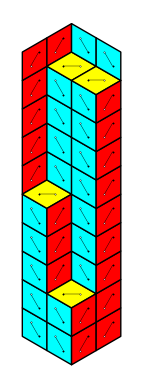

In [191]:
n  = 2
a,b,c = 5,1,1
A,B,C = int(round(n*a)),int(round(n*b)),int(round(n*c))
H = RT.Hexagon(n,a=a,b=b,c=c)
H.shuffle()
M = H.get_edge_matrix()
fig,P,L=draw_lozenges_dimer(M,A,B,C,1,dpi=100)
ax = fig.axes[0]

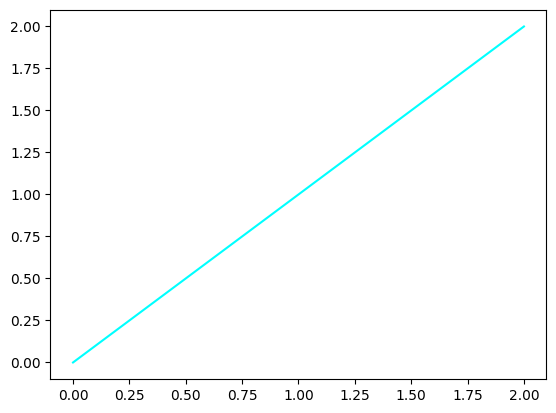

In [5]:
plt.plot(range(3),range(3),c = (0,1,1))